# Phase 5/7 — Notebook 27: Regime Confirmation Under the v3 Trigger

**Notebook:** `notebooks/07_phase5_adaptation/27_regime_confirm_v3.ipynb`
**Pre-registration:** **A6** (commit with date + git hash BEFORE running). Requires `src/adaptation/trigger_v3.py` (promoted from nb26 v3 per its ARTIFACT-FIXED-V3 verdict).

**Purpose.** Close the trigger arc: nb22 confirmed the corrected regime gates (D040, 4 seeds) with the legacy trigger and reported quiet-window false alarms as a limitation; nb26 v3 fixed the trigger (A5). This notebook re-runs nb22's exact multi-seed sweep with the **v3 trigger as the cheap policy** and tests, per A6.3:

- **Regime gates (D040, unchanged):** G1 / G2a / G2b on frozen vs ceiling — trigger-independent; all 4 seeds.
- **G-FA-27:** pooled quiet false fires across all 12 seed×breadth streams ≤ 1 (per-stream counts + exceedances reported; prediction: 0).
- **G-DET-27:** first fire within 2 windows of onset in every stream (prediction: exactly 1).
- **G-CHEAP-27:** v3 cheap (triggered_persist_2500) recovers recall at the hardest breadth (≥ frozen + 0.05) in every seed; comparison to nb22's stored cheap values reported, not gated (prediction P-A6-3: v3 ≥ nb22 in ≥ 9/12 cells — the clean-pool effect).

**This is the final Phase-5/7 experiment (A6.5): whatever the verdict, the next step is writing.**

**Runtime:** nb22's sweep + 200 permutation draws × 12 streams — expect 60–120 min.

## 1. Environment + pre-registered configuration (A6)

In [1]:
import sys
from pathlib import Path
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
except Exception:
    pass
THESIS_ROOT = Path('/content/drive/MyDrive/phd_thesis')
if str(THESIS_ROOT) not in sys.path:
    sys.path.insert(0, str(THESIS_ROOT))

import numpy as np, pandas as pd, json, math, glob, inspect, time
from datetime import date
import matplotlib.pyplot as plt

from src.utils.seeding import set_global_seed
from src.utils.io import path
from src.utils.documentation import log_finding
from src.streaming.replay import train_detector
from src.adaptation.cost_eval import run_instrumented, micro_metrics
from src.adaptation.trigger_v3 import tau_v3, run_triggered_persist
from src.monitoring.ks_monitor import per_feature_ks
assert 'always_cheap' in inspect.getsource(run_instrumented), 'run nb20 cost_eval cell first.'

# --- nb22 config (D040), verbatim ---
RF_KW = dict(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
SEEDS         = [42, 7, 123, 2024]
BREADTHS      = [1, 2, 4]
WINDOW_SIZE   = 5000
QUIET_WINDOWS = 10
TRAIN_BENIGN  = 25000
HARD_RECALL_MAX, RECOVER_MIN, FLIP_MARGIN = 0.70, 0.15, 0.05
CICIDS_REF = dict(regime='CICIDS catastrophic (nb19 ref)',
                  frozen=0.000, ceiling=0.909, cheap=0.913)

# --- v3 trigger config (A5, validated) ---
BURN_IN, N_PERM, PERM_Q, K_PERSIST = 4, 200, 0.999, 2
L_MAX = 2
POOLED_FA_MAX = 1     # G-FA-27: pooled fires over all 12 streams
print('Config set. seeds =', SEEDS, '| breadths =', BREADTHS,
      '| trigger = v3 (benign-only ref, persistence K=2, perm-quantile tau)')

Mounted at /content/drive
Config set. seeds = [42, 7, 123, 2024] | breadths = [1, 2, 4] | trigger = v3 (benign-only ref, persistence K=2, perm-quantile tau)


## 2. Load UNSW (nb21/22 inline loader, verbatim)

In [2]:
def _find_unsw_files():
    for sub in ('data/processed', 'data/interim', 'data/raw'):
        d = THESIS_ROOT / sub
        if not d.exists():
            continue
        hits = []
        for p in ('unsw*.parquet', 'UNSW*.parquet', '*unsw*.parquet'):
            hits += list(d.rglob(p))
        if hits:
            return ('parquet', sorted(set(hits)))
    for sub in ('data/raw', 'data/raw/unsw_nb15', 'data/raw/UNSW-NB15'):
        d = THESIS_ROOT / sub
        if d.exists():
            csvs = [c for c in sorted(d.rglob('*.csv')) if 'unsw' in c.name.lower()]
            if csvs:
                return ('csv', csvs)
    return (None, [])

def _pick(df, names):
    low = {c.lower(): c for c in df.columns}
    for nm in names:
        if nm.lower() in low:
            return low[nm.lower()]
    return None

kind, files = _find_unsw_files()
assert kind is not None, 'No UNSW parquet/csv found.'
df_raw = (pd.concat([pd.read_parquet(p) for p in files], ignore_index=True) if kind == 'parquet'
          else pd.concat([pd.read_csv(p, low_memory=False) for p in files], ignore_index=True))
cat_col = _pick(df_raw, ['attack_category', 'attack_cat', 'attackcat', 'category'])
lab_col = _pick(df_raw, ['label', 'Label', 'is_attack'])
id_like = [c for c in df_raw.columns if c.lower() in (
    'id', 'srcip', 'dstip', 'sport', 'dsport', 'stime', 'ltime', 'source_file', 'attempted')]
fams = df_raw[cat_col].astype(str).str.strip().str.lower().replace(
    {'': 'benign', 'normal': 'benign', 'nan': 'benign', '-': 'benign'})
feat = df_raw.drop(columns=[c for c in [cat_col, lab_col] + id_like if c], errors='ignore')
feat = feat.apply(pd.to_numeric, errors='coerce')
feat = feat.loc[:, feat.notna().mean() > 0.99].fillna(0.0).astype('float32')
X_all = feat.to_numpy(); fam = fams.to_numpy()
y_attack = (fam != 'benign').astype(int); is_benign = (fam == 'benign')
attack_order = list(pd.Series(fam[y_attack == 1]).value_counts().index)
print(f'UNSW {kind}: {feat.shape[1]} features; families {attack_order}')

UNSW parquet: 42 features; families ['generic', 'exploits', 'fuzzers', 'dos', 'reconnaissance', 'analysis', 'backdoor', 'shellcode', 'worms']


## 3. Helpers — nb22's seed-parametrized regime builder (verbatim) + benign positions

In [3]:
def windows_of(n, size):
    b = list(range(0, n, size)) + [n]
    return [(b[i], b[i + 1]) for i in range(len(b) - 1)]

def build_regime(seen_fams, seed):
    novel_fams = [f for f in attack_order if f not in seen_fams]
    rng = np.random.default_rng(seed)
    benign_idx = np.where(is_benign)[0]; rng.shuffle(benign_idx)
    seen_idx = np.where(np.isin(fam, seen_fams))[0]
    novel_idx = np.where(np.isin(fam, novel_fams))[0]; rng.shuffle(novel_idx)
    n_trb = min(TRAIN_BENIGN, len(benign_idx) // 2)
    warm = np.concatenate([benign_idx[:n_trb], seen_idx]); rng.shuffle(warm)
    Xtr, ytr = X_all[warm], y_attack[warm]
    warm_benign_pos = np.flatnonzero(y_attack[warm] == 0)
    rest = benign_idx[n_trb:]; q_take = min(len(rest), QUIET_WINDOWS * WINDOW_SIZE)
    quiet_rows = rest[:q_take]; drift_benign = rest[q_take:]
    n_fill = min(len(drift_benign), len(novel_idx))
    drift_rows = np.concatenate([novel_idx, drift_benign[:n_fill]]); rng.shuffle(drift_rows)
    stream_idx = np.concatenate([quiet_rows, drift_rows])
    Xs, ys, fam_s = X_all[stream_idx], y_attack[stream_idx], fam[stream_idx]
    wins = windows_of(len(Xs), WINDOW_SIZE)
    is_drift = [bool(np.isin(fam_s[a:b], novel_fams).any()) for (a, b) in wins]
    return Xtr, ytr, warm_benign_pos, Xs, ys, wins, is_drift
print('helpers ready.')

helpers ready.


## 4. Multi-seed sweep — frozen / ceiling (nb22 verbatim) + v3 cheap policies

Per (seed, breadth): the regime gates' quantities (`never`, `always_sliding`)
run on the full stream exactly as nb22; the v3 trigger runs Phase-II style —
its burn-in windows are Phase-I nulls, monitored/accounted from window 4.

In [4]:
records = []
t0 = time.time()
for seed in SEEDS:
    set_global_seed(seed)
    rf = dict(RF_KW); rf['random_state'] = seed
    for b in BREADTHS:
        seen = attack_order[:b]
        Xtr, ytr, bpos, Xs, ys, wins, is_drift = build_regime(seen, seed)
        det0 = train_detector(Xtr, ytr, rf)

        # regime-gate policies (trigger-independent), nb22 verbatim
        nev = run_instrumented(Xs, ys, wins, det0, rf, policy='never', seed=seed)
        asl = run_instrumented(Xs, ys, wins, det0, rf, policy='always_sliding', seed=seed)
        frozen = micro_metrics(nev['per_window'], mask=is_drift)['recall']
        ceiling = micro_metrics(asl['per_window'], mask=is_drift)['recall']

        # v3 monitor: benign-only reference + tau_v3
        bperm = np.random.default_rng(seed).permutation(len(bpos))
        half = len(bpos) // 2
        REF_T = Xtr[bpos[bperm[:half]]]
        CAL_T = Xtr[bpos[bperm[half:]]]
        burn = [Xs[wins[i][0]:wins[i][1]] for i in range(BURN_IN)]
        cal = tau_v3(REF_T, CAL_T, burn, WINDOW_SIZE,
                     n_perm=N_PERM, perm_q=PERM_Q, seed=seed)

        start = wins[BURN_IN][0]
        wins_t = [(a - start, c - start) for (a, c) in wins[BURN_IN:]]
        Xs_t, ys_t = Xs[start:], ys[start:]
        drift_t = is_drift[BURN_IN:]
        quiet_t = [i for i, d in enumerate(drift_t) if not d]
        onset_t = next(i for i, d in enumerate(drift_t) if d)

        t25 = run_triggered_persist(Xs_t, ys_t, wins_t, det0, rf,
                                    reference0=REF_T, tau=cal['tau_eff'],
                                    budget=2500, k_persist=K_PERSIST, seed=seed)
        t250 = run_triggered_persist(Xs_t, ys_t, wins_t, det0, rf,
                                     reference0=REF_T, tau=cal['tau_eff'],
                                     budget=250, k_persist=K_PERSIST, seed=seed)
        cheap = micro_metrics(t25['per_window'], mask=drift_t)['recall']
        cheap250 = micro_metrics(t250['per_window'], mask=drift_t)['recall']
        trg = set(t250['triggers'])
        fires_q = sum(1 for i in quiet_t if i in trg)
        exc_q = [i for i in quiet_t if i in set(t250['exceedances'])]
        lat = next((i for i in sorted(trg) if i >= onset_t), None)
        lat = None if lat is None else lat - onset_t

        records.append(dict(seed=seed, breadth=b, frozen=frozen, ceiling=ceiling,
                            cheap=cheap, cheap250=cheap250,
                            tau_eff=cal['tau_eff'], tau_perm=cal['tau_perm'],
                            fires_quiet=fires_q, n_quiet=len(quiet_t),
                            exceed_quiet=exc_q, latency=lat,
                            labels_250=t250['label_cost']))
        r = records[-1]
        print(f"seed {seed:>4} breadth {b}: frozen {frozen:.3f} ceiling {ceiling:.3f} "
              f"cheap_v3 {cheap:.3f} | fires {fires_q}/{len(quiet_t)} "
              f"exceed@{exc_q} lat {lat} ({time.time()-t0:.0f}s)")

df = pd.DataFrame(records)
df.to_csv(path('reports', 'tables') / '27_regime_confirm_v3_raw.csv', index=False)
# consistency: seed-42 frozen values should match nb21/22 (0.630/0.691/0.984)
s42 = df[df.seed == 42].set_index('breadth')['frozen'].round(3).to_dict()
print('seed-42 frozen by breadth (nb21/22: {1:0.630, 2:0.691, 4:0.984}):', s42)

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_f

seed   42 breadth 1: frozen 0.630 ceiling 0.958 cheap_v3 0.966 | fires 0/6 exceed@[] lat 1 (21s)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_f

seed   42 breadth 2: frozen 0.691 ceiling 0.933 cheap_v3 0.956 | fires 0/6 exceed@[] lat 1 (36s)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_f

...

seed 2024 breadth 1: frozen 0.642 ceiling 0.958 cheap_v3 0.970 | fires 0/6 exceed@[] lat 1 (161s)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_f

seed 2024 breadth 2: frozen 0.676 ceiling 0.933 cheap_v3 0.958 | fires 0/6 exceed@[] lat 1 (177s)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_f

seed 2024 breadth 4: frozen 0.982 ceiling 0.862 cheap_v3 0.988 | fires 0/6 exceed@[] lat 1 (192s)
seed-42 frozen by breadth (nb21/22: {1:0.630, 2:0.691, 4:0.984}): {1: 0.63, 2: 0.691, 4: 0.984}


## 5. Gates (A6.3): D040 regime gates + v3 trigger gates

In [5]:
def seed_gates(g):
    by_b = {int(r.breadth): r for r in g.itertuples()}
    hard = min(by_b.values(), key=lambda r: r.frozen)
    mild = max(by_b.values(), key=lambda r: r.frozen)
    g1 = bool(hard.frozen < HARD_RECALL_MAX)
    g2a = bool(hard.ceiling >= hard.frozen + RECOVER_MIN)
    benefit_h = hard.ceiling - hard.frozen
    benefit_m = mild.ceiling - mild.frozen
    g2b = bool((benefit_m <= -FLIP_MARGIN) and (benefit_h >= FLIP_MARGIN))
    g_cheap = bool(hard.cheap >= hard.frozen + 0.05)
    return dict(seed=int(g['seed'].iloc[0]), hard_breadth=int(hard.breadth),
                frozen_hard=round(hard.frozen, 3), ceiling_hard=round(hard.ceiling, 3),
                cheap_hard=round(hard.cheap, 3),
                benefit_mild=round(benefit_m, 3), benefit_hard=round(benefit_h, 3),
                G1=g1, G2a=g2a, G2b=g2b, G_CHEAP=g_cheap)

gate_rows = [seed_gates(df[df.seed == s]) for s in SEEDS]
gates = pd.DataFrame(gate_rows)
display(gates)
gates.to_csv(path('reports', 'tables') / '27_regime_confirm_v3_gates.csv', index=False)

regime_ok = bool(gates[['G1', 'G2a', 'G2b']].all().all())
pooled_fires = int(df['fires_quiet'].sum())
g_fa27 = bool(pooled_fires <= POOLED_FA_MAX)
g_det27 = bool(((df['latency'].notna()) & (df['latency'] <= L_MAX)).all())
g_cheap27 = bool(gates['G_CHEAP'].all())

verdict = ('REGIME-CONFIRMED-UNDER-V3'
           if (regime_ok and g_fa27 and g_det27 and g_cheap27)
           else 'REGIME-OK-TRIGGER-GATE-FAILED' if regime_ok
           else 'REGIME-GATES-FAILED-UNDER-RESEED')

print('=' * 76)
print('NOTEBOOK 27 — A6 VERDICT')
print('=' * 76)
print(f'  D040 regime gates (G1, G2a, G2b) all seeds: {regime_ok}')
print(f'  G-FA-27 pooled quiet fires over 12 streams: {pooled_fires} '
      f'(gate <= {POOLED_FA_MAX}) -> {g_fa27}')
print(f'  G-DET-27 latency <= {L_MAX} in every stream: {g_det27} '
      f"(latencies: {sorted(df['latency'].dropna().unique().tolist())})")
print(f'  G-CHEAP-27 cheap_v3 >= frozen+0.05 at hardest, all seeds: {g_cheap27}')
print('-' * 76)
print(f'--> VERDICT: {verdict}')

,seed,hard_breadth,frozen_hard,ceiling_hard,cheap_hard,benefit_mild,benefit_hard,G1,G2a,G2b,G_CHEAP
0,42,1,0.630,0.958,0.966,-0.119,0.327,True,True,True,True
1,7,1,0.646,0.958,0.970,-0.117,0.312,True,True,True,True
2,123,1,0.651,0.958,0.971,-0.120,0.307,True,True,True,True
3,2024,1,0.642,0.958,0.970,-0.120,0.316,True,True,True,True


NOTEBOOK 27 — A6 VERDICT
  D040 regime gates (G1, G2a, G2b) all seeds: True
  G-FA-27 pooled quiet fires over 12 streams: 0 (gate <= 1) -> True
  G-DET-27 latency <= 2 in every stream: True (latencies: [1])
  G-CHEAP-27 cheap_v3 >= frozen+0.05 at hardest, all seeds: True
----------------------------------------------------------------------------
--> VERDICT: REGIME-CONFIRMED-UNDER-V3


## 6. Comparison to nb22 (stored) — the clean-pool effect (P-A6-3, reported)

Loads nb22's stored per-seed summary if present; otherwise transcribe nb22's
cheap values into `NB22_CHEAP` manually and re-run this cell.

In [9]:
# --- Section 6 (fixed): compare v3 cheap vs nb22's stored per-seed raw CSV ---
nb22_csv = path('reports', 'tables') / '22_per_seed_raw.csv'
assert nb22_csv.exists(), f'{nb22_csv} not found — check reports/tables/'
nb22 = pd.read_csv(nb22_csv)[['seed', 'breadth', 'frozen', 'ceiling', 'cheap']]
nb22 = nb22.rename(columns={'frozen': 'frozen_nb22', 'ceiling': 'ceiling_nb22',
                            'cheap': 'cheap_nb22'})

comp = df[['seed', 'breadth', 'cheap']].merge(nb22, on=['seed', 'breadth'])
comp['delta_v3_minus_nb22'] = (comp['cheap'] - comp['cheap_nb22']).round(3)
display(comp)

# P-A6-3a: v3 cheap beats nb22 cheap in >= 9/12 cells
wins = int((comp['delta_v3_minus_nb22'] > 0).sum())
print(f'P-A6-3a: v3 cheap > nb22 cheap in {wins}/12 cells (prediction: >= 9/12) '
      f'-> {"CONFIRMED" if wins >= 9 else "NOT CONFIRMED"}')

# P-A6-3b: at each seed's hardest breadth, v3 closes >= half of nb22's
# (ceiling - cheap) gap, in >= 3/4 seeds
rows_b = []
for s in SEEDS:
    g22 = nb22[nb22.seed == s]
    hard_b = int(g22.loc[g22['frozen_nb22'].idxmin(), 'breadth'])
    old = g22[g22.breadth == hard_b].iloc[0]
    new_cheap = float(comp[(comp.seed == s) & (comp.breadth == hard_b)]['cheap'].iloc[0])
    gap_old = float(old['ceiling_nb22'] - old['cheap_nb22'])
    closed = float(new_cheap - old['cheap_nb22'])
    frac = closed / gap_old if gap_old > 0 else float('inf')
    rows_b.append(dict(seed=s, hard_breadth=hard_b,
                       cheap_nb22=round(float(old['cheap_nb22']), 3),
                       ceiling_nb22=round(float(old['ceiling_nb22']), 3),
                       cheap_v3=round(new_cheap, 3),
                       gap_closed_frac=(round(frac, 2) if gap_old > 0 else 'gap<=0')))
gapdf = pd.DataFrame(rows_b)
display(gapdf)
n_half = int(sum(1 for r in rows_b
                 if r['gap_closed_frac'] == 'gap<=0' or
                 (isinstance(r['gap_closed_frac'], float) and r['gap_closed_frac'] >= 0.5)))
print(f'P-A6-3b: >= half the ceiling-cheap gap closed at the hardest breadth in '
      f'{n_half}/4 seeds (prediction: >= 3/4) '
      f'-> {"CONFIRMED" if n_half >= 3 else "NOT CONFIRMED"}')

comp.to_csv(path('reports', 'tables') / '27_cheap_v3_vs_nb22.csv', index=False)
gapdf.to_csv(path('reports', 'tables') / '27_gap_closing_v3.csv', index=False)
print('saved: 27_cheap_v3_vs_nb22.csv, 27_gap_closing_v3.csv')

,seed,breadth,cheap,frozen_nb22,ceiling_nb22,cheap_nb22,delta_v3_minus_nb22
0,42,1,0.965842,0.630177,0.957628,0.867970,0.098
1,42,2,0.955905,0.691189,0.933417,0.913589,0.042
2,42,4,0.986749,0.983848,0.864494,0.841667,0.145
3,7,1,0.969556,0.645914,0.957695,0.782452,0.187
4,7,2,0.953751,0.688758,0.933140,0.780913,0.173
5,7,4,0.979060,0.978286,0.861060,0.812748,0.166
6,123,1,0.970558,0.650857,0.957817,0.897762,0.073
7,123,2,0.959332,0.699104,0.933564,0.832482,0.127
8,123,4,0.985057,0.981623,0.861254,0.829094,0.156
9,2024,1,0.969670,0.642256,0.957902,0.935994,0.034


P-A6-3a: v3 cheap > nb22 cheap in 12/12 cells (prediction: >= 9/12) -> CONFIRMED


,seed,hard_breadth,cheap_nb22,ceiling_nb22,cheap_v3,gap_closed_frac
0,42,1,0.868,0.958,0.966,1.09
1,7,1,0.782,0.958,0.970,1.07
2,123,1,0.898,0.958,0.971,1.21
3,2024,1,0.936,0.958,0.970,1.54


P-A6-3b: >= half the ceiling-cheap gap closed at the hardest breadth in 4/4 seeds (prediction: >= 3/4) -> CONFIRMED
saved: 27_cheap_v3_vs_nb22.csv, 27_gap_closing_v3.csv


## 7. Crossover figure — nb22's regime curve, v3 selectivity annotated

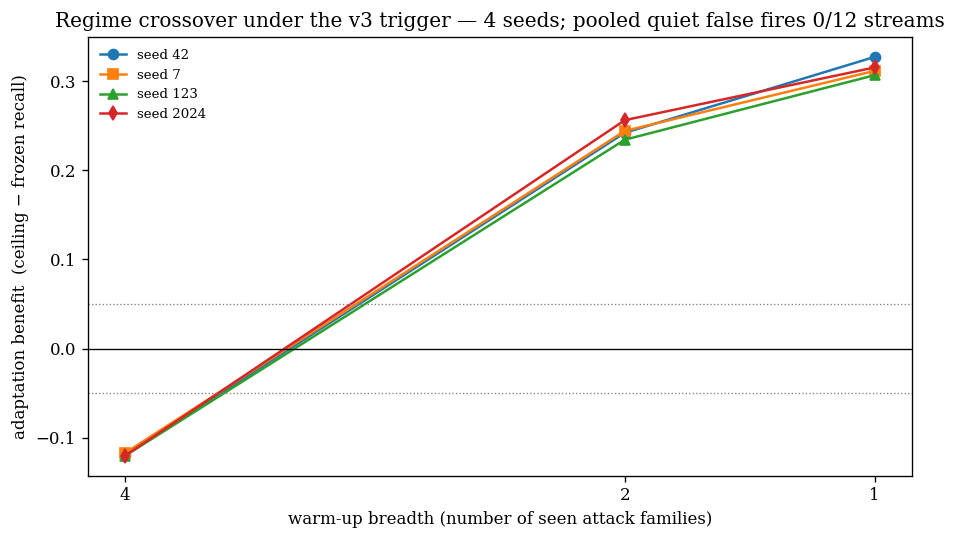

In [7]:
plt.rcParams.update({'font.family': 'serif', 'font.size': 10,
                     'figure.dpi': 120, 'savefig.dpi': 300})
fig, ax = plt.subplots(figsize=(7.8, 4.6))
for s, mk in zip(SEEDS, ['o', 's', '^', 'd']):
    g = df[df.seed == s].sort_values('breadth')
    ax.plot(g['breadth'], g['ceiling'] - g['frozen'], mk + '-', label=f'seed {s}')
ax.axhline(0, color='black', lw=0.8)
ax.axhline(FLIP_MARGIN, ls=':', color='grey', lw=0.8)
ax.axhline(-FLIP_MARGIN, ls=':', color='grey', lw=0.8)
ax.set_xticks(BREADTHS); ax.invert_xaxis()
ax.set_xlabel('warm-up breadth (number of seen attack families)')
ax.set_ylabel('adaptation benefit  (ceiling − frozen recall)')
pooled = int(df['fires_quiet'].sum())
ax.set_title(f'Regime crossover under the v3 trigger — 4 seeds; '
             f'pooled quiet false fires {pooled}/12 streams')
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
for ext in ['png', 'pdf']:
    fig.savefig(path('reports', 'figures') / f'27_regime_crossover_v3.{ext}')
plt.show()

## 8. Save summary + log (free IDs — check the decisions log)

In [8]:
summary = dict(
    notebook='27_regime_confirm_v3', prereg='A6', generated=str(date.today()),
    seeds=SEEDS, breadths=BREADTHS,
    trigger='v3 (src.adaptation.trigger_v3): benign-only ref, tau_v3, K_PERSIST=2',
    gates=dict(regime_D040_all_seeds=bool(regime_ok),
               G_FA_27=dict(pooled_fires=pooled_fires, max=POOLED_FA_MAX,
                            passed=bool(g_fa27)),
               G_DET_27=bool(g_det27), G_CHEAP_27=bool(g_cheap27)),
    per_seed_gates=gate_rows,
    records=df.to_dict(orient='records'),
    cicids_ref=CICIDS_REF, verdict=verdict)
out = path('data', 'processed') / 'phase7_27_regime_confirm_v3.json'
with open(out, 'w') as f:
    json.dump(summary, f, indent=2, default=str)
print('Saved', out)

# log_decision -> A6 design under the next FREE D-ID (backfill D031/D032 first).
# log_finding(
#     finding_id='F0XX',
#     title='Regime confirmation under the v3 trigger: <verdict>',
#     context='07_phase5_adaptation/27_regime_confirm_v3',
#     what_we_did='Re-ran the nb22 4-seed corrected-gate sweep with the v3 '
#                 'trigger (benign-only ref + persistence + perm-quantile tau) '
#                 'as the cheap policy.',
#     what_we_found='<regime gates per seed; pooled fires; latencies; cheap_v3 '
#                   'vs nb22 deltas>',
#     why_it_matters='Closes the trigger arc: regime conclusions are trigger-'
#                    'version-invariant and the selectivity limitation is gone '
#                    'at 12-stream scale. FINAL Phase-5/7 experiment (A6.5).',
# )

Saved /content/drive/MyDrive/phd_thesis/data/processed/phase7_27_regime_confirm_v3.json


In [10]:
summary['p_a6_3'] = dict(wins_of_12=wins, gap_closed_seeds=n_half,
                         a='CONFIRMED' if wins >= 9 else 'NOT CONFIRMED',
                         b='CONFIRMED' if n_half >= 3 else 'NOT CONFIRMED')
with open(path('data', 'processed') / 'phase7_27_regime_confirm_v3.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)
print('summary updated with P-A6-3.')

summary updated with P-A6-3.


## 9. Terminus (A6.5)

No further experiments after this notebook, regardless of verdict:
- **REGIME-CONFIRMED-UNDER-V3** → paper #2's trigger + regime sections are
  numerically complete. Coding is DONE; start writing.
- **REGIME-OK-TRIGGER-GATE-FAILED** → regime story stands; the failed trigger
  gate is reported verbatim in the selectivity subsection. Coding DONE.
- **REGIME-GATES-FAILED-UNDER-RESEED** → a seed-sensitivity finding about the
  regime construction (not the trigger); reported verbatim. Coding DONE.
Notebook 28 (2018 stream) stays in Future Work.